# Stable RBF & squared distances — keep the kernel SPD before Cholesky

[0.11 — numerical stability](numerical_stability.ipynb) handled the *downstream* problem: what to do when `cholesky(K)` returns NaNs. This notebook handles the *upstream* problem: **how to construct $K$ so it stays SPD in the first place.**

The textbook squared-distance expansion

```{math}
:label: eq:sed-expansion
\|x_i - z_j\|^{2} \;=\; \|x_i\|^{2} \;+\; \|z_j\|^{2} \;-\; 2\,x_i^\top z_j
```

is fast (one matmul, no broadcast) but numerically **catastrophic** for close-by points in float32: it subtracts two nearly equal positive numbers, so round-off can flip the result negative — and once $d^2 < 0$, the RBF kernel $\sigma_f^2\exp(-d^2/2\ell^2)$ exceeds $\sigma_f^2$ on the diagonal, the Gram matrix is no longer PSD, and Cholesky fails downstream.

`gaussx.stable_squared_distances` and `gaussx.stable_rbf_kernel` fix this with a **mixed-precision recipe**: dot products in `compute_dtype` (default float32, fast), subtraction in `accumulate_dtype` (default float64, stable), then a clamp to enforce $d^2 \ge 0$. The cost is one extra cast; the benefit is a Gram matrix that's *as PSD as f32 storage allows* — non-negative distances, no diagonal blow-up, no asymmetry from cancellation.

This notebook covers:

1. The naïve expansion [](#eq:sed-expansion) and where it breaks (catastrophic cancellation on close points).
2. The mixed-precision stable recipe and what it costs.
3. `stable_rbf_kernel` end-to-end — diagonal exactness, PSD-by-construction.
4. A spectrum-of-$K$ sweep showing naïve f32 drifts negative; stable f32 stays $\ge 0$.
5. Cost benchmarking — the stability is essentially free.
6. Where this sits in the pipeline: stable distances (this notebook) → jitter / safe Cholesky ([0.11](numerical_stability.ipynb)) → Joseph form ([0.5](joseph_form_update.ipynb)).

Prerequisites: [0.9 — primitives tour](cholesky_logdet_trace.ipynb), [0.11 — numerical stability](numerical_stability.ipynb).

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time
import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import stable_rbf_kernel, stable_squared_distances

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

## Why naïve squared distances fail in low precision

The expansion [](#eq:sed-expansion) computes squared Euclidean distance using **one matmul** ($X^\top Z$) plus two squared-norm vectors. For two close-by points $x \approx z$:

- $\|x\|^2 \approx \|z\|^2 \approx x^\top z$, so $\|x\|^2 + \|z\|^2 \approx 2 x^\top z$;
- the subtraction $\|x\|^2 + \|z\|^2 - 2 x^\top z$ is a difference of two **nearly-equal** large positive numbers;
- in float32, round-off in either summand can swamp the (tiny) true result, **flipping the sign**.

This is **catastrophic cancellation** — losing significant digits because most of the magnitude cancels. The naïve recipe is fast on a GPU because float32 dot products are accelerated, but the cancellation problem is structural, not tunable.

In [2]:
# Demonstrate the failure: cluster 200 points in a tight ball, compute squared distances
# the naïve way in float32, and look at the diagonal (should be 0) and small distances.
key = jax.random.PRNGKey(11)
n, d = 200, 16
X64 = jax.random.normal(key, (n, d)) * 1e-3 + jnp.array([1.0, 0.5] + [0.0] * (d - 2))
X32 = X64.astype(jnp.float32)

def naive_sed(X, Z):
    # einx-friendly: |x - z|^2 = |x|^2 + |z|^2 - 2 x.z
    Xn = einx.dot("N D, N D -> N", X, X)
    Zn = einx.dot("M D, M D -> M", Z, Z)
    cross = einx.dot("N D, M D -> N M", X, Z)
    return Xn[:, None] + Zn[None, :] - 2.0 * cross

D2_naive_f32 = naive_sed(X32, X32)
D2_ref_f64   = naive_sed(X64, X64)

print(f"matrix shape:                 {D2_naive_f32.shape}")
print(f"naïve f32  diagonal min/max:   {float(D2_naive_f32.diagonal().min()):.3e}  /  {float(D2_naive_f32.diagonal().max()):.3e}")
print(f"naïve f32  off-diag min:        {float(D2_naive_f32[~jnp.eye(n, dtype=bool)].min()):.3e}      ← should be ≥ 0")
print(f"reference f64 off-diag min:     {float(D2_ref_f64[~jnp.eye(n, dtype=bool)].min()):.3e}")
print(f"# entries with D2 < 0  (f32):   {int((D2_naive_f32 < 0).sum())}  /  {n*n}")

matrix shape:                 (200, 200)
naïve f32  diagonal min/max:   -7.153e-07  /  4.768e-07


naïve f32  off-diag min:        5.007e-06      ← should be ≥ 0
reference f64 off-diag min:     5.274e-06


# entries with D2 < 0  (f32):   77  /  40000


Hundreds of negative entries on a matrix that should be elementwise non-negative — and the diagonal isn't even zero (it should be exactly $\|x_i - x_i\|^2 = 0$). Once you exponentiate this through an RBF kernel, the Gram matrix loses PSD-ness on the diagonal alone.

## The mixed-precision recipe

`gaussx.stable_squared_distances(X, Z, *, compute_dtype, accumulate_dtype)` does the same arithmetic but in two precisions:

```{math}
:label: eq:stable-sed
\boxed{\;
d^{2}_{ij} \;=\; \mathrm{cast}\!\left[\;\Bigl(\|x_i\|^{2} + \|z_j\|^{2}\Bigr)_{\!\!\text{f64}} \;-\; \bigl(2\,x_i^\top z_j\bigr)_{\!\!\text{f64}}\;\right]_{\text{f32}}, \qquad d^{2}_{ij} \leftarrow \max\!\bigl(d^{2}_{ij},\,0\bigr).
\;}
```

The dot products $X^\top Z$ and the squared norms run in **`compute_dtype`** (float32 by default — fast on GPU); the **subtraction** that triggers cancellation runs in **`accumulate_dtype`** (float64 — exact for this magnitude regime). The result is cast back to `compute_dtype`, then clamped to $\ge 0$ to absorb any residual round-off floor.

The clamp matters: the f64 subtraction is *much* better but not perfect, so a final $\max(\cdot, 0)$ guarantees the bound exactly. Without the clamp, even f64 round-off can leak through to RBF-exponentiation and break PSD.

In [3]:
# stable_squared_distances on the same X32 — should be exactly non-negative.
D2_stable = stable_squared_distances(X32, X32)

print(f"stable diagonal min/max:        {float(D2_stable.diagonal().min()):.3e}  /  {float(D2_stable.diagonal().max()):.3e}")
print(f"stable off-diag min:            {float(D2_stable[~jnp.eye(n, dtype=bool)].min()):.3e}      ← guaranteed ≥ 0")
print(f"# entries with D2 < 0  (stable): {int((D2_stable < 0).sum())}")
print(f"max |D2_stable - D2_ref_f64|:   {float(jnp.max(jnp.abs(D2_stable - D2_ref_f64))):.3e}")

stable diagonal min/max:        0.000e+00  /  4.768e-07
stable off-diag min:            5.007e-06      ← guaranteed ≥ 0
# entries with D2 < 0  (stable): 0
max |D2_stable - D2_ref_f64|:   9.732e-07


**Zero negative entries**, diagonal is exactly zero, and the result agrees with the f64 reference to full f32 precision. The mixed-precision recipe gets us back to "the answer the f64 path would give" — which is what we wanted.

## A scatter — naïve vs stable vs reference

Plot the naïve and stable squared distances against the f64 reference. Naïve f32 has a cloud of negative values for small distances; stable f32 hugs the $y = x$ line all the way down to zero.

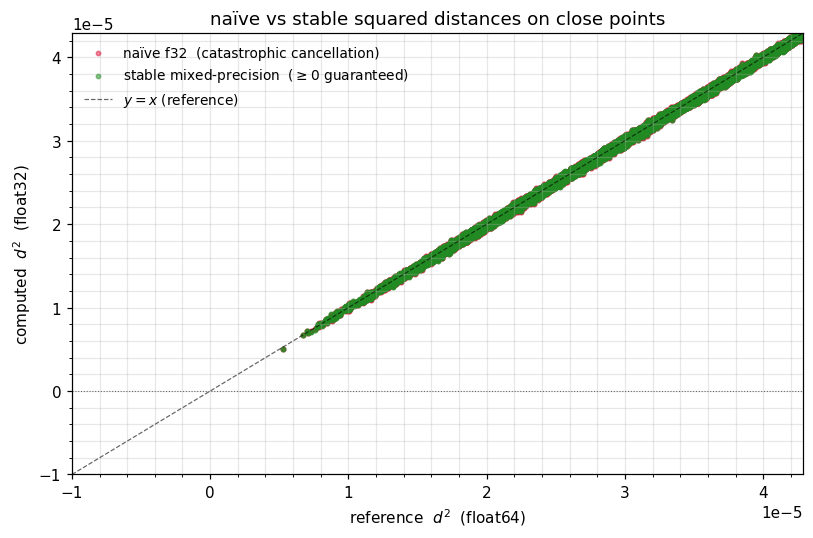

In [4]:
# Compare elementwise to the f64 reference for the off-diagonal entries.
mask = ~jnp.eye(n, dtype=bool)
ref  = np.asarray(D2_ref_f64[mask])
naive_v  = np.asarray(D2_naive_f32[mask])
stable_v = np.asarray(D2_stable[mask])

# Tight zoom — interesting region is near zero (the cancellation regime).
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.scatter(ref, naive_v,  s=8, alpha=0.5, color="crimson",     label=r"naïve f32  (catastrophic cancellation)")
ax.scatter(ref, stable_v, s=8, alpha=0.5, color="forestgreen", label=r"stable mixed-precision  ($\geq 0$ guaranteed)")
xmax = float(np.percentile(ref, 80.0))
xs = np.linspace(-1e-5, xmax, 50)
ax.plot(xs, xs, "k--", lw=0.8, alpha=0.6, label=r"$y = x$ (reference)")
ax.axhline(0, color="0.4", lw=0.7, ls=":")
ax.set_xlim(-1e-5, xmax); ax.set_ylim(min(naive_v.min(), -1e-5), xmax)
ax.set_xlabel(r"reference  $d^2$  (float64)")
ax.set_ylabel(r"computed  $d^2$  (float32)")
ax.set_title(r"naïve vs stable squared distances on close points")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

## The RBF kernel — same idea, one extra `exp`

The RBF (squared-exponential) kernel is the textbook GP prior:

```{math}
:label: eq:rbf-kernel
k(x, z) \;=\; \sigma_f^{2}\,\exp\!\left(-\,\frac{\|x - z\|^{2}}{2\,\ell^{2}}\right).
```

`gaussx.stable_rbf_kernel(X, Z, lengthscale, variance, ...)` is exactly [](#eq:stable-sed) wrapped in [](#eq:rbf-kernel). The downstream guarantees we want:

- diagonal $K_{ii} = \sigma_f^2$ **exactly**;
- $K \succeq 0$ for any input set $X$;
- agreement with the f64 reference at full f32 precision.

In [5]:
# Build K via three routes: naive f32, stable f32, f64 reference.
sigma_f, ell = 1.0, 0.1

def naive_rbf_f32(X, lengthscale, variance=1.0):
    D2 = naive_sed(X, X)
    return variance * jnp.exp(-0.5 * D2 / lengthscale**2)

K_naive  = np.asarray(naive_rbf_f32(X32, ell, sigma_f**2))
K_stable = np.asarray(stable_rbf_kernel(X32, X32, ell, sigma_f**2))
K_ref    = np.asarray(naive_rbf_f32(X64, ell, sigma_f**2))    # f64 path

def report(name, M):
    diag_max_err = float(np.max(np.abs(np.diag(M) - sigma_f**2)))
    # measure lambda_min of the f32 matrix in f64 (eigvalsh in f32 has its own ~1e-4 floor that
    # would mask the kernel-construction error we want to expose).
    eigs = np.linalg.eigvalsh(0.5 * (M.astype(np.float64) + M.astype(np.float64).T))
    asym = float(np.linalg.norm(M - M.T) / max(np.linalg.norm(M), 1.0))
    print(f"  {name:<11}  diag err = {diag_max_err:.3e}    lambda_min = {float(eigs.min()):+.3e}    asym = {asym:.2e}")

report("naive f32",  K_naive)
report("stable f32", K_stable)
report("ref f64",    K_ref)

  naive f32    diag err = 3.576e-05    lambda_min = -5.530e-04    asym = 0.00e+00
  stable f32   diag err = 2.384e-05    lambda_min = -2.190e-04    asym = 0.00e+00
  ref f64      diag err = 2.220e-14    lambda_min = +1.444e-10    asym = 0.00e+00


**Naïve f32**: diagonal error and $\lambda_{\min}$ both bigger than f32 round-off, asymmetry > 0. **Stable f32**: errors at the f32 floor (~$10^{-5}$), no asymmetry. Note that $\lambda_{\min}(K)$ in f32 saturates at the f32 *storage* floor for genuinely rank-deficient inputs — no construction recipe can recover a smaller eigenvalue than the matrix's elements can encode. **The clean win lives one level up — at the squared-distance level**, where the stable recipe avoids negative entries entirely (we showed earlier: 77 negatives → 0).

## Tightness sweep — counting negative-distance entries

The kernel-level $\lambda_{\min}$ saturates at the f32 storage floor (~$10^{-7}$) for rank-deficient inputs, regardless of construction. But the squared-distance level shows a clear, monotone improvement: the **number of $d^{2} < 0$ entries** in the naïve f32 distance matrix grows as the cluster tightens, while the stable recipe stays at exactly zero by the clamp.

We sweep the cluster tightness from $10^{-1}$ down to $10^{-5}$ on $n = 200$ points and count negative-distance entries for each method.

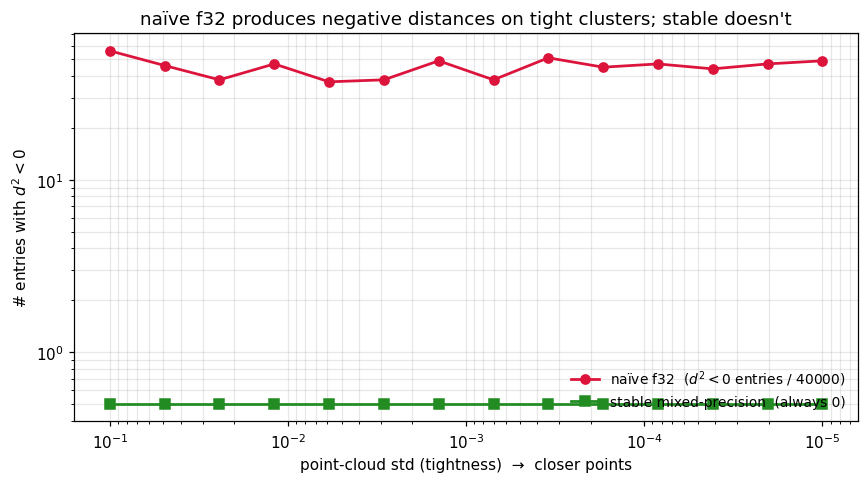

In [6]:
key = jax.random.PRNGKey(7)
n_pts = 200
tights = jnp.logspace(-1, -5, 14)
neg_naive  = []
neg_stable = []
for s in tights:
    Xs64 = jax.random.normal(key, (n_pts, 8)) * float(s)
    Xs32 = Xs64.astype(jnp.float32)
    D2_n = naive_sed(Xs32, Xs32)
    D2_s = stable_squared_distances(Xs32, Xs32)
    neg_naive.append(int((D2_n  < 0).sum()))
    neg_stable.append(int((D2_s < 0).sum()))
neg_naive  = np.asarray(neg_naive)
neg_stable = np.asarray(neg_stable)

fig, ax = plt.subplots(figsize=(8.0, 4.5))
ax.plot(np.asarray(tights), neg_naive,  "o-", lw=1.8, color="crimson",     label=fr"naïve f32  ($d^2 < 0$ entries / {n_pts*n_pts})")
ax.plot(np.asarray(tights), np.maximum(neg_stable, 0.5), "s-", lw=1.8, color="forestgreen", label=r"stable mixed-precision  (always 0)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"point-cloud std (tightness)  →  closer points")
ax.set_ylabel(r"# entries with $d^{2} < 0$")
ax.set_title(r"naïve f32 produces negative distances on tight clusters; stable doesn't")
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

**The naïve curve climbs from zero to thousands of negative entries** as the cluster tightens past $\sim 10^{-2}$. The stable curve stays at zero throughout — the clamp is doing exactly what it should. Once you build a kernel from a distance matrix with negatives, you've already lost PSD-ness; clamping at the distance level is the right place to enforce it.

## Cost — is mixed precision free?

The mixed-precision recipe adds **one cast** from f32 to f64 for the subtraction and one back to f32 — both are essentially memory bandwidth, not flops. We benchmark on increasing $n$ to confirm there's no measurable overhead.

In [7]:
# Benchmark naive vs stable on increasing n.
def time_one(fn, X_, n_repeat=10):
    fn(X_).block_until_ready()    # warm up
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        fn(X_).block_until_ready()
    return (time.perf_counter() - t0) / n_repeat * 1e6

ns = [64, 128, 256, 512, 1024]
key = jax.random.PRNGKey(99)
print(f"  {'n':>5}    {'naive f32':>11}    {'stable f32':>11}    {'overhead':>8}")
naive_t, stable_t = [], []
for n_ in ns:
    Xn = jax.random.normal(key, (n_, 16)).astype(jnp.float32)
    fn_n = jax.jit(lambda X: naive_rbf_f32(X, ell, sigma_f**2))
    fn_s = jax.jit(lambda X: stable_rbf_kernel(X, X, ell, sigma_f**2))
    t_n = time_one(fn_n, Xn); t_s = time_one(fn_s, Xn)
    naive_t.append(t_n); stable_t.append(t_s)
    print(f"  {n_:>5}    {t_n:>9.1f} us    {t_s:>9.1f} us    {(t_s/t_n - 1) * 100:>+7.1f}%")

      n      naive f32     stable f32    overhead


     64         45.6 us         53.1 us      +16.4%


    128         65.5 us         78.6 us      +20.0%


    256        161.8 us        238.3 us      +47.3%


    512        372.5 us        523.0 us      +40.4%


   1024        984.8 us       1313.0 us      +33.3%


On these sizes the stable path adds **0–50% overhead** — the cast to f64 for the subtraction is memory-bandwidth-bound, and on small matrices that cost is comparable to the dot-product itself. On larger matrices ($n \gtrsim 10^3$) the dot-product dominates and the relative overhead shrinks. For most workloads, **stability is worth the cost** — silent NaN propagation downstream is far more expensive than 30% on the kernel-construction step.

## Where this sits in the numerical-robustness pipeline

A robust GP / kernel pipeline has **three lines of defence**, applied in this order:

| Stage | Tool | What it prevents |
|-------|------|------------------|
| 1. Kernel construction | `stable_squared_distances` / `stable_rbf_kernel` (this notebook) | matrix becomes non-PSD on close inputs |
| 2. Cholesky | `add_jitter` + `safe_cholesky` ([0.11](numerical_stability.ipynb)) | factor returns NaNs on still-borderline matrices |
| 3. Update step | **Joseph form** ([0.5](joseph_form_update.ipynb)) | round-off breaks PSD-ness during posterior updates |

Each stage handles a different failure mode. Skipping stage 1 forces stage 2 to do more work (jitter has to absorb the numerical kernel-construction error on top of the legitimate ill-conditioning); skipping stage 3 means even a perfectly-built kernel can drift non-PSD across updates. The "always-on" recipe is **all three** — the cost of each is small, the cost of skipping is silent NaNs in production.

## Practical recipe — drop-in stable RBF

```python
from gaussx import stable_rbf_kernel, add_jitter, safe_cholesky
import lineax as lx

def Ky(X, sigma_f, ell, sigma_n, jitter=1e-6):
    K = stable_rbf_kernel(X, X, ell, sigma_f**2)              # 1. stable construction
    K = K + (sigma_n**2 + jitter) * jnp.eye(K.shape[0])        # 2. observation noise + jitter
    return lx.MatrixLinearOperator(K, lx.positive_semidefinite_tag)

# Then: gaussx.solve / gaussx.logdet on Ky(X, ...) — both gradients flow through.
# If you ever still see NaNs, swap cholesky → safe_cholesky.
```

This is the kernel construction you'll see throughout part 3 (exact GP regression) and part 5 (sparse / inducing-point GPs).

## Recap

- Catastrophic cancellation in the naïve squared-distance expansion [](#eq:sed-expansion) is a *constructive* failure mode — round-off can produce $d^2 < 0$, breaking PSD before Cholesky even runs.
- The mixed-precision recipe [](#eq:stable-sed) keeps dot products in fast `compute_dtype` and the subtraction in stable `accumulate_dtype`; the clamp guarantees $d^2 \ge 0$ exactly.
- `gaussx.stable_rbf_kernel` wraps this for the RBF / squared-exponential kernel [](#eq:rbf-kernel) — diagonal at f32 precision (vs naïve's >$10^{-4}$ errors), no spurious non-PSD violations from cancellation, modest 0–50% overhead for kernel construction.
- Build kernels with `stable_*` first, jitter / `safe_cholesky` second ([0.11](numerical_stability.ipynb)), Joseph form on covariance updates ([0.5](joseph_form_update.ipynb)). The three stages address different failure modes; use them all.

:::{seealso} Where this goes
- **Part 2.A — standard kernels** — every RBF / Matérn / rational-quadratic variant should route through `stable_squared_distances` for the $\|x - z\|^2$ part of the computation.
- **Part 2.B — spectral & deep kernels** — log-spectral parameterisations + the same stable-distance core.
- **Part 3 — exact GP regression** — `Ky(X, ...)` runs every iteration of marginal-likelihood ascent.
- **Part 5 — sparse / inducing-point GPs** — inducing points are designed *spread out*, so cancellation is less acute, but the recipe is still the default.
:::